# Unit08_Association_Rule_Learning_Overview | 關聯規則學習總覽

本 Notebook 整合 `Part_2/Unit08/` 的核心概念，以互動式程式碼演練關聯規則學習的理論基礎與化工應用。

## 目標
- 計算並驗證支持度、置信度、提升度三大核心指標
- 逐步追蹤 Apriori 演算法與 FP-Growth 演算法的執行過程
- 比較兩種演算法在速度與結果上的差異
- 計算 Conviction、Leverage、Zhang's Metric 等進階指標
- 練習多種規則過濾策略
- 繪製 Support-Confidence 散佈圖、規則網絡圖、矩陣熱力圖等視覺化
- 將關聯規則應用於模擬化工配方數據並解讀結果

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'P2_Unit08_Association_Rule_Learning_Overview'
SOURCE_DATA_DIR = 'chemical_formulations'

try:
  from google.colab import drive
  IN_COLAB = True
  print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
  drive.mount('/content/drive', force_remount=True)
except ImportError:
  IN_COLAB = False
  print("✓ 偵測到 Local 環境")
try:
  shortcut_path = '/content/ChemE-3590'
  os.remove(shortcut_path)
except FileNotFoundError:
  pass

if IN_COLAB:
  source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3590')
  os.symlink(source_path, shortcut_path)
  shortcut_path = Path(shortcut_path)
  if source_path.exists():
    NOTEBOOK_DIR = shortcut_path / 'Part_2' / 'Unit08'
    OUTPUT_DIR = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    DATA_DIR = NOTEBOOK_DIR / 'data' / SOURCE_DATA_DIR
    FIG_DIR = OUTPUT_DIR / 'figs'
  else:
    print(f"⚠️ 找不到路徑雲端ChemE-3590路徑，請確認自己的雲端資料夾是否正確")

else:
  NOTEBOOK_DIR = Path.cwd()
  OUTPUT_DIR = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
  DATA_DIR = NOTEBOOK_DIR / 'data' / SOURCE_DATA_DIR
  FIG_DIR = OUTPUT_DIR / 'figs'

NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 數據來源目錄: {DATA_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3590\Part_2\Unit08
✓ 數據來源目錄: d:\MyGit\ChemE-3590\Part_2\Unit08\data\chemical_formulations
✓ 結果輸出目錄: d:\MyGit\ChemE-3590\Part_2\Unit08\outputs\P2_Unit08_Association_Rule_Learning_Overview
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3590\Part_2\Unit08\outputs\P2_Unit08_Association_Rule_Learning_Overview\figs


---
### 1. 載入相關套件

In [2]:
# 基礎套件
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Association Rule Mining 套件
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# 網絡圖視覺化
import networkx as nx

# 統計檢驗
from scipy.stats import chi2_contingency

# 設定隨機種子
SEED = 42
np.random.seed(SEED)

# 設定 matplotlib
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print("✓ 套件載入完成")

✓ 套件載入完成


---
## 2. 關聯規則基本概念演練

### 2.1 手動計算三大核心指標

本節以 **5 筆化工配方交易** 為例，逐步手算支持度 (Support)、置信度 (Confidence)、提升度 (Lift)，驗證公式定義。

| 交易ID | 項目集 |
|--------|--------|
| T1 | 催化劑A, 溶劑X, 高溫 |
| T2 | 催化劑A, 溶劑Y, 高溫 |
| T3 | 催化劑B, 溶劑X, 低溫 |
| T4 | 催化劑A, 溶劑X, 高溫, 高產率 |
| T5 | 催化劑A, 溶劑X |

In [3]:
# ====================================================
# 2.1 手動計算三大核心指標
# ====================================================

# 定義 5 筆交易記錄
transactions_demo = [
    {'催化劑A', '溶劑X', '高溫'},         # T1
    {'催化劑A', '溶劑Y', '高溫'},         # T2
    {'催化劑B', '溶劑X', '低溫'},         # T3
    {'催化劑A', '溶劑X', '高溫', '高產率'},  # T4
    {'催化劑A', '溶劑X'},                  # T5
]

N = len(transactions_demo)
print(f"總交易數 N = {N}")
print()

# ─── 計算各項目集的出現次數 ───
def count_itemset(transactions, itemset):
    """計算包含 itemset 的交易數"""
    count = sum(1 for t in transactions if itemset.issubset(t))
    return count

# 單一項目支持度
items_demo = ['催化劑A', '催化劑B', '溶劑X', '溶劑Y', '高溫', '低溫', '高產率']
print("=== L1：單一項目支持度 ===")
print(f"{'項目':<12} {'出現次數':>6} {'支持度':>8}")
print("-" * 28)
for item in items_demo:
    cnt = count_itemset(transactions_demo, {item})
    sup = cnt / N
    threshold = "✓" if sup >= 0.4 else "✗"
    print(f"{item:<12} {cnt:>6}     {sup:>6.2f}  {threshold}")

print()

# 計算規則 {催化劑A} => {高產率} 的三大指標
X = {'催化劑A'}
Y = {'高產率'}
X_union_Y = X | Y

cnt_X = count_itemset(transactions_demo, X)
cnt_Y = count_itemset(transactions_demo, Y)
cnt_XY = count_itemset(transactions_demo, X_union_Y)

support_X = cnt_X / N
support_Y = cnt_Y / N
support_XY = cnt_XY / N
confidence = support_XY / support_X
lift = confidence / support_Y

print("=== 規則評估：{催化劑A} => {高產率} ===")
print(f"  Support(催化劑A)        = {cnt_X}/{N} = {support_X:.2f}")
print(f"  Support(高產率)         = {cnt_Y}/{N} = {support_Y:.2f}")
print(f"  Support(催化劑A ∪ 高產率) = {cnt_XY}/{N} = {support_XY:.2f}")
print()
print(f"  Support    = {support_XY:.2f}  ({support_XY*100:.0f}% 的配方同時有催化劑A且高產率)")
print(f"  Confidence = {confidence:.2f}  (使用催化劑A中，{confidence*100:.0f}% 達到高產率)")
print(f"  Lift       = {lift:.2f}  (使用催化劑A使高產率機率提升 {(lift-1)*100:.0f}%)")

總交易數 N = 5

=== L1：單一項目支持度 ===
項目             出現次數      支持度
----------------------------
催化劑A              4       0.80  ✓
催化劑B              1       0.20  ✗
溶劑X               4       0.80  ✓
溶劑Y               1       0.20  ✗
高溫                3       0.60  ✓
低溫                1       0.20  ✗
高產率               1       0.20  ✗

=== 規則評估：{催化劑A} => {高產率} ===
  Support(催化劑A)        = 4/5 = 0.80
  Support(高產率)         = 1/5 = 0.20
  Support(催化劑A ∪ 高產率) = 1/5 = 0.20

  Support    = 0.20  (20% 的配方同時有催化劑A且高產率)
  Confidence = 0.25  (使用催化劑A中，25% 達到高產率)
  Lift       = 1.25  (使用催化劑A使高產率機率提升 25%)


### 2.2 使用 mlxtend 自動計算並驗證手算結果

In [4]:
# ====================================================
# 2.2 One-Hot Encoding 並用 mlxtend 驗證
# ====================================================

# 建立 One-Hot 格式 DataFrame
data_demo = pd.DataFrame({
    '催化劑A':  [1, 1, 0, 1, 1],
    '催化劑B':  [0, 0, 1, 0, 0],
    '溶劑X':    [1, 0, 1, 1, 1],
    '溶劑Y':    [0, 1, 0, 0, 0],
    '高溫':     [1, 1, 0, 1, 0],
    '低溫':     [0, 0, 1, 0, 0],
    '高產率':   [0, 0, 0, 1, 0],
}, dtype=bool)

print("One-Hot 編碼後的交易矩陣：")
print(data_demo.astype(int).to_string())
print()

# 使用 Apriori 挖掘頻繁項目集
freq_items_demo = apriori(data_demo, min_support=0.4, use_colnames=True)
print(f"\n頻繁項目集 (min_support=0.4)：共 {len(freq_items_demo)} 個")
print(freq_items_demo.sort_values('support', ascending=False).to_string(index=False))

# 生成關聯規則（min_confidence=0.6）
rules_demo = association_rules(freq_items_demo, metric="confidence", min_threshold=0.6,
                               num_itemsets=len(freq_items_demo))
print(f"\n關聯規則 (min_confidence=0.6)：共 {len(rules_demo)} 條")
print(rules_demo[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string(index=False))

# ── 手動驗證 {催化劑A} => {高產率} ──
print("\n=== 手動驗證規則 {催化劑A} => {高產率} ===")
print(f"  Confidence = {support_XY:.2f} / {support_X:.2f} = {confidence:.2f}")
print(f"  此規則 Confidence={confidence:.2f} < min_confidence=0.6，")
print(f"  故正確地被過濾掉，不出現在規則集中。")

# ── 驗證高信度規則：{高溫} => {催化劑A} ──
rule_check = rules_demo[
    (rules_demo['antecedents'] == frozenset({'高溫'})) &
    (rules_demo['consequents'] == frozenset({'催化劑A'}))
]
if not rule_check.empty:
    r = rule_check.iloc[0]
    # 手算
    cnt_ht = count_itemset(transactions_demo, {'高溫'})
    cnt_ca = count_itemset(transactions_demo, {'催化劑A'})
    cnt_ht_ca = count_itemset(transactions_demo, {'高溫', '催化劑A'})
    conf_manual = (cnt_ht_ca / 5) / (cnt_ht / 5)
    lift_manual = conf_manual / (cnt_ca / 5)
    print(f"\n✓ 驗證規則 {{高溫}} => {{催化劑A}}：")
    print(f"  手算: Confidence={conf_manual:.3f}, Lift={lift_manual:.3f}")
    print(f"  mlxtend: Confidence={r['confidence']:.3f}, Lift={r['lift']:.3f}")
    print(f"  {'✓ 手算與 mlxtend 結果完全一致！' if abs(conf_manual - r['confidence']) < 1e-9 else '✗ 結果不一致，請檢查'}")

One-Hot 編碼後的交易矩陣：
   催化劑A  催化劑B  溶劑X  溶劑Y  高溫  低溫  高產率
0     1     0    1    0   1   0    0
1     1     0    0    1   1   0    0
2     0     1    1    0   0   1    0
3     1     0    1    0   1   0    1
4     1     0    1    0   0   0    0


頻繁項目集 (min_support=0.4)：共 7 個
 support        itemsets
     0.8          (催化劑A)
     0.8           (溶劑X)
     0.6            (高溫)
     0.6     (催化劑A, 溶劑X)
     0.6      (催化劑A, 高溫)
     0.4       (溶劑X, 高溫)
     0.4 (催化劑A, 溶劑X, 高溫)

關聯規則 (min_confidence=0.6)：共 9 條
antecedents consequents  support  confidence     lift
     (催化劑A)       (溶劑X)      0.6    0.750000 0.937500
      (溶劑X)      (催化劑A)      0.6    0.750000 0.937500
     (催化劑A)        (高溫)      0.6    0.750000 1.250000
       (高溫)      (催化劑A)      0.6    1.000000 1.250000
       (高溫)       (溶劑X)      0.4    0.666667 0.833333
(催化劑A, 溶劑X)        (高溫)      0.4    0.666667 1.111111
 (催化劑A, 高溫)       (溶劑X)      0.4    0.666667 0.833333
  (溶劑X, 高溫)      (催化劑A)      0.4    1.000000 1.250000
       (高

---
## 3. Apriori 演算法逐步追蹤

本節以同一個 5 筆交易範例，逐步顯示 Apriori 演算法每一輪掃描的頻繁項目集生成過程。

In [5]:
# ====================================================
# 3. Apriori 演算法逐步追蹤
# ====================================================
from itertools import combinations

MIN_SUPPORT = 0.4  # 出現在至少 2 筆交易中

# 使用 set 表示每筆交易
transactions_set = [frozenset(t) for t in transactions_demo]
N_TXN = len(transactions_set)

def get_support(transactions, itemset):
    cnt = sum(1 for t in transactions if itemset.issubset(t))
    return cnt / len(transactions)

def apriori_step(transactions, candidates, min_sup):
    """從候選集中篩選頻繁項目集"""
    freq = {}
    for c in candidates:
        s = get_support(transactions, c)
        if s >= min_sup:
            freq[c] = round(s, 2)
    return freq

def generate_candidates(freq_prev, k):
    """由 L_{k-1} 生成候選 C_k（兩兩合併且前 k-2 個項目相同）"""
    freq_list = sorted([sorted(list(f)) for f in freq_prev])
    candidates = set()
    for i in range(len(freq_list)):
        for j in range(i + 1, len(freq_list)):
            l1, l2 = freq_list[i], freq_list[j]
            # 前 k-2 個元素相同才合併
            if l1[:k-2] == l2[:k-2]:
                candidate = frozenset(l1) | frozenset(l2)
                if len(candidate) == k:
                    candidates.add(candidate)
    return candidates

# ─── 第 1 次掃描：L1 ───
all_items = set()
for t in transactions_set:
    all_items |= t
C1 = [frozenset([item]) for item in all_items]
L1 = apriori_step(transactions_set, C1, MIN_SUPPORT)

print(f"min_support = {MIN_SUPPORT} (至少出現 {int(MIN_SUPPORT * N_TXN)} 次)")
print()
print("=== 第 1 次掃描：L1 (1-項目集) ===")
for k, v in sorted(L1.items(), key=lambda x: -x[1]):
    print(f"  {set(k)}  support={v}")

# ─── 第 2 次掃描：L2 ───
C2 = generate_candidates(L1.keys(), 2)
L2 = apriori_step(transactions_set, C2, MIN_SUPPORT)

print()
print("=== 第 2 次掃描：L2 (2-項目集) ===")
for k, v in sorted(L2.items(), key=lambda x: -x[1]):
    print(f"  {set(k)}  support={v}")

# ─── 第 3 次掃描：L3 ───
C3 = generate_candidates(L2.keys(), 3)
L3 = apriori_step(transactions_set, C3, MIN_SUPPORT)

print()
print("=== 第 3 次掃描：L3 (3-項目集) ===")
for k, v in sorted(L3.items(), key=lambda x: -x[1]):
    print(f"  {set(k)}  support={v}")

# ─── 嘗試 L4（無法再擴展）───
C4 = generate_candidates(L3.keys(), 4)
print()
print(f"=== 嘗試 L4：候選集數量 = {len(C4)} → 演算法終止 ===")
print()
print("✓ 最終頻繁項目集總數:", len(L1) + len(L2) + len(L3))

min_support = 0.4 (至少出現 2 次)

=== 第 1 次掃描：L1 (1-項目集) ===
  {'催化劑A'}  support=0.8
  {'溶劑X'}  support=0.8
  {'高溫'}  support=0.6

=== 第 2 次掃描：L2 (2-項目集) ===
  {'催化劑A', '溶劑X'}  support=0.6
  {'催化劑A', '高溫'}  support=0.6
  {'溶劑X', '高溫'}  support=0.4

=== 第 3 次掃描：L3 (3-項目集) ===
  {'催化劑A', '溶劑X', '高溫'}  support=0.4

=== 嘗試 L4：候選集數量 = 0 → 演算法終止 ===

✓ 最終頻繁項目集總數: 7


---
## 4. Apriori vs FP-Growth 速度與結果比較

本節以**模擬化工配方數據集（500筆）**，同時執行 Apriori 與 FP-Growth，比較執行時間與結果一致性。

In [6]:
# ====================================================
# 4.1 生成模擬化工配方數據集
# ====================================================
np.random.seed(SEED)

n_samples = 500

# 定義選項
catalysts   = ['Cat_A', 'Cat_B', 'Cat_C']
solvents    = ['Solvent_X', 'Solvent_Y', 'Solvent_Z']
temps       = ['Low_Temp', 'Optimal_Temp', 'High_Temp']
pressures   = ['Low_Press', 'Med_Press', 'High_Press']
additives   = ['Add_1', 'Add_2', 'Add_3', 'No_Additive']
yields      = ['Excellent_Yield', 'Good_Yield', 'Poor_Yield']
purities    = ['High_Purity', 'Med_Purity', 'Low_Purity']

transactions_raw = []
for _ in range(n_samples):
    txn = []

    # 催化劑（Cat_A 較常見）
    cat = np.random.choice(catalysts, p=[0.45, 0.35, 0.20])
    txn.append(cat)

    # 溶劑
    sol = np.random.choice(solvents, p=[0.40, 0.35, 0.25])
    txn.append(sol)

    # 溫度
    temp = np.random.choice(temps, p=[0.25, 0.50, 0.25])
    txn.append(temp)

    # 壓力
    press = np.random.choice(pressures, p=[0.30, 0.40, 0.30])
    txn.append(press)

    # 添加劑（75% 機率加一種）
    if np.random.rand() < 0.75:
        add = np.random.choice(['Add_1', 'Add_2', 'Add_3'], p=[0.40, 0.35, 0.25])
        txn.append(add)
    else:
        txn.append('No_Additive')

    # ── 嵌入設計好的關聯規則 ──
    # Rule 1: Cat_A + Optimal_Temp → Excellent_Yield (80%)
    if cat == 'Cat_A' and temp == 'Optimal_Temp':
        yield_val = 'Excellent_Yield' if np.random.rand() < 0.80 else 'Good_Yield'
    # Rule 2: Solvent_X + High_Press → High_Purity (75%)
    elif sol == 'Solvent_X' and press == 'High_Press':
        yield_val = np.random.choice(yields, p=[0.50, 0.35, 0.15])
    # Rule 3: Cat_B + Low_Temp → Poor_Yield (70%)
    elif cat == 'Cat_B' and temp == 'Low_Temp':
        yield_val = 'Poor_Yield' if np.random.rand() < 0.70 else 'Good_Yield'
    else:
        yield_val = np.random.choice(yields, p=[0.30, 0.45, 0.25])
    txn.append(yield_val)

    # 純度（與溶劑X+高壓組合關聯）
    if sol == 'Solvent_X' and press == 'High_Press':
        purity_val = 'High_Purity' if np.random.rand() < 0.75 else np.random.choice(purities)
    else:
        purity_val = np.random.choice(purities, p=[0.40, 0.40, 0.20])
    txn.append(purity_val)

    transactions_raw.append(txn)

# ── 轉換為 One-Hot DataFrame ──
# 注意：確保欄位名稱為原生 Python str，避免 mlxtend 的 numpy.str_ 相容性問題
te = TransactionEncoder()
te_array = te.fit_transform(transactions_raw)
col_names = [str(c) for c in te.columns_]          # 確保為純 Python str
df_chem = pd.DataFrame(te_array, columns=col_names)

print(f"化工配方數據集規模：{df_chem.shape[0]} 筆交易 × {df_chem.shape[1]} 個項目")
print(f"\n項目列表：{list(df_chem.columns)}")
print(f"\n各項目出現頻率：")
freq_check = df_chem.sum().sort_values(ascending=False)
for item, cnt in freq_check.items():
    print(f"  {item:<20} {cnt:>4} 次  ({cnt/n_samples*100:.1f}%)")

化工配方數據集規模：500 筆交易 × 22 個項目

項目列表：['Add_1', 'Add_2', 'Add_3', 'Cat_A', 'Cat_B', 'Cat_C', 'Excellent_Yield', 'Good_Yield', 'High_Press', 'High_Purity', 'High_Temp', 'Low_Press', 'Low_Purity', 'Low_Temp', 'Med_Press', 'Med_Purity', 'No_Additive', 'Optimal_Temp', 'Poor_Yield', 'Solvent_X', 'Solvent_Y', 'Solvent_Z']

各項目出現頻率：
  Optimal_Temp          251 次  (50.2%)
  High_Purity           220 次  (44.0%)
  Cat_A                 212 次  (42.4%)
  Excellent_Yield       211 次  (42.2%)
  Med_Press             199 次  (39.8%)
  Solvent_X             197 次  (39.4%)
  Cat_B                 194 次  (38.8%)
  Med_Purity            182 次  (36.4%)
  Good_Yield            180 次  (36.0%)
  Solvent_Y             170 次  (34.0%)
  High_Press            156 次  (31.2%)
  Add_1                 146 次  (29.2%)
  Low_Press             145 次  (29.0%)
  Solvent_Z             133 次  (26.6%)
  Add_2                 132 次  (26.4%)
  No_Additive           131 次  (26.2%)
  Low_Temp              126 次  (25.2%)
  High_Temp   

In [7]:
# ====================================================
# 4.2 Apriori vs FP-Growth 執行時間與結果比較
# ====================================================
MIN_SUP = 0.05
MIN_CONF = 0.6

# ── Apriori ──
t0 = time.time()
freq_apriori = apriori(df_chem, min_support=MIN_SUP, use_colnames=True)
rules_apriori = association_rules(freq_apriori, metric="confidence",
                                  min_threshold=MIN_CONF)
t_apriori = time.time() - t0

# ── FP-Growth ──
t0 = time.time()
freq_fpgrowth = fpgrowth(df_chem, min_support=MIN_SUP, use_colnames=True)
rules_fpgrowth = association_rules(freq_fpgrowth, metric="confidence",
                                   min_threshold=MIN_CONF)
t_fpgrowth = time.time() - t0

# ── 結果比較 ──
print("=" * 55)
print(f"{'項目':<28} {'Apriori':>12} {'FP-Growth':>12}")
print("-" * 55)
print(f"{'執行時間 (秒)':<28} {t_apriori:>12.4f} {t_fpgrowth:>12.4f}")
print(f"{'頻繁項目集數量':<28} {len(freq_apriori):>12} {len(freq_fpgrowth):>12}")
print(f"{'關聯規則數量':<28} {len(rules_apriori):>12} {len(rules_fpgrowth):>12}")
print("=" * 55)

# ── 驗證結果一致性 ──
# 兩種方法應找到完全相同的頻繁項目集
sets_a = set(
    (frozenset(row['itemsets']), round(row['support'], 6))
    for _, row in freq_apriori.iterrows()
)
sets_f = set(
    (frozenset(row['itemsets']), round(row['support'], 6))
    for _, row in freq_fpgrowth.iterrows()
)
same = sets_a == sets_f
print(f"\n✓ 兩種演算法結果完全一致：{same}")
print(f"  (頻繁項目集相同，僅執行速度有差異)")

項目                                Apriori    FP-Growth
-------------------------------------------------------
執行時間 (秒)                           0.0196       0.0365
頻繁項目集數量                               400          400
關聯規則數量                                 88           88

✓ 兩種演算法結果完全一致：True
  (頻繁項目集相同，僅執行速度有差異)


---
## 5. 規則評估指標計算

本節計算 Conviction、Leverage、Zhang's Metric、Kulczynski 等進階指標，並與 Support / Confidence / Lift 整合呈現。

In [8]:
# ====================================================
# 5. 進階評估指標計算
# ====================================================

# 使用 FP-Growth 的規則集（已含 support / confidence / lift）
rules_eval = rules_fpgrowth.copy()

# ── Conviction ──
# conviction = (1 - support(Y)) / (1 - confidence(X→Y))
# 當 confidence=1 時 conviction=inf，需特別處理
def calc_conviction(conf, sup_y):
    denom = 1 - conf
    if denom == 0:
        return np.inf
    return (1 - sup_y) / denom

rules_eval['conviction'] = rules_eval.apply(
    lambda r: calc_conviction(r['confidence'], r['consequent support']), axis=1
)

# ── Leverage ──
# leverage = support(X∪Y) - support(X) * support(Y)
rules_eval['leverage'] = (
    rules_eval['support'] -
    rules_eval['antecedent support'] * rules_eval['consequent support']
)

# ── Zhang's Metric ──
def calc_zhang(sup_xy, sup_x, sup_y):
    numerator = sup_xy - sup_x * sup_y
    denom = max(sup_x * (1 - sup_y), sup_y * (1 - sup_x))
    if denom == 0:
        return 0.0
    return numerator / denom

rules_eval['zhang'] = rules_eval.apply(
    lambda r: calc_zhang(r['support'], r['antecedent support'], r['consequent support']),
    axis=1
)

# ── Kulczynski ──
rules_eval['kulczynski'] = 0.5 * (
    rules_eval['confidence'] +
    rules_eval['support'] / rules_eval['consequent support']
)

# ── 顯示 Top-10 規則（依 Conviction 排序）──
cols_show = ['antecedents', 'consequents', 'support', 'confidence',
             'lift', 'conviction', 'leverage', 'zhang', 'kulczynski']
top10 = rules_eval[cols_show].sort_values('conviction', ascending=False).head(10)

print("Top-10 關聯規則（依 Conviction 降序）：\n")
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_colwidth', 30)
print(top10.to_string(index=False))

Top-10 關聯規則（依 Conviction 降序）：

                          antecedents       consequents  support  confidence  lift  conviction  leverage  zhang  kulczynski
    (Cat_A, High_Press, Optimal_Temp) (Excellent_Yield)    0.060       0.909 2.154       6.358     0.032  0.082       0.526
   (Cat_A, High_Purity, Optimal_Temp) (Excellent_Yield)    0.078       0.867 2.054       4.335     0.040  0.104       0.526
     (Cat_A, Solvent_Y, Optimal_Temp) (Excellent_Yield)    0.074       0.860 2.039       4.142     0.038  0.098       0.518
     (Cat_A, Solvent_X, Optimal_Temp) (Excellent_Yield)    0.060       0.857 2.031       4.046     0.030  0.078       0.500
             (Add_3, Excellent_Yield)    (Optimal_Temp)    0.062       0.861 1.715       3.586     0.026  0.056       0.492
    (Cat_A, Med_Purity, Optimal_Temp) (Excellent_Yield)    0.068       0.829 1.965       3.385     0.033  0.086       0.495
                (Cat_A, Optimal_Temp) (Excellent_Yield)    0.174       0.829 1.963       3.372     0.

---
## 6. 規則過濾策略

本節演練四種過濾策略：
1. **Lift 閾值過濾**（移除 Lift < 1.2 的規則）
2. **卡方統計顯著性過濾**（p-value > 0.05）
3. **規則長度限制**（前項最多 2 個項目）
4. **冗餘規則移除**（高置信度簡單規則優先）

In [9]:
# ====================================================
# 6. 規則過濾策略
# ====================================================
rules_filter = rules_eval.copy()
N_data = len(df_chem)

print(f"過濾前規則數量：{len(rules_filter)}")

# ─── 策略 1：Lift 閾值過濾 ───
before = len(rules_filter)
rules_filter = rules_filter[rules_filter['lift'] >= 1.2]
print(f"\n[策略1] Lift >= 1.2 過濾後：{len(rules_filter)} 條（移除 {before - len(rules_filter)} 條）")

# ─── 策略 2：卡方統計顯著性過濾 (p-value <= 0.05) ───
def chi_square_pvalue(rule, N):
    """計算 2x2 列聯表的 p-value"""
    sup_xy = rule['support']
    sup_x  = rule['antecedent support']
    sup_y  = rule['consequent support']
    n11 = sup_xy * N
    n10 = (sup_x - sup_xy) * N
    n01 = (sup_y - sup_xy) * N
    n00 = N - n11 - n10 - n01
    table = [[max(n11, 0.5), max(n10, 0.5)],
             [max(n01, 0.5), max(n00, 0.5)]]
    _, p, _, _ = chi2_contingency(table, correction=False)
    return p

rules_filter['chi2_pvalue'] = rules_filter.apply(
    lambda r: chi_square_pvalue(r, N_data), axis=1
)
before = len(rules_filter)
rules_filter = rules_filter[rules_filter['chi2_pvalue'] <= 0.05]
print(f"[策略2] 卡方顯著性 p<=0.05 後：{len(rules_filter)} 條（移除 {before - len(rules_filter)} 條）")

# ─── 策略 3：規則長度限制（前項 <= 2 個項目）───
before = len(rules_filter)
rules_filter = rules_filter[rules_filter['antecedents'].apply(len) <= 2]
print(f"[策略3] 前項長度 <= 2 後：{len(rules_filter)} 條（移除 {before - len(rules_filter)} 條）")

# ─── 策略 4：綜合評分排序（Confidence 0.5, Lift 0.3, Support 0.2）───
rules_filter['score'] = (
    0.5 * rules_filter['confidence'] +
    0.3 * (rules_filter['lift'] / rules_filter['lift'].max()) +
    0.2 * rules_filter['support']
)
rules_filter = rules_filter.sort_values('score', ascending=False)

print(f"\n過濾後規則數量：{len(rules_filter)}")
print("\n=== Top-10 最有價值的化工配方規則 ===\n")
for i, (_, row) in enumerate(rules_filter.head(10).iterrows(), 1):
    ants = ', '.join(sorted(list(row['antecedents'])))
    cons = ', '.join(sorted(list(row['consequents'])))
    print(f"  規則 {i:2d}: {{{ants}}} => {{{cons}}}")
    print(f"          Support={row['support']:.3f}, "
          f"Confidence={row['confidence']:.3f}, "
          f"Lift={row['lift']:.2f}, "
          f"Score={row['score']:.3f}")

過濾前規則數量：88

[策略1] Lift >= 1.2 過濾後：88 條（移除 0 條）
[策略2] 卡方顯著性 p<=0.05 後：86 條（移除 2 條）
[策略3] 前項長度 <= 2 後：51 條（移除 35 條）

過濾後規則數量：51

=== Top-10 最有價值的化工配方規則 ===

  規則  1: {Cat_A, Optimal_Temp} => {Excellent_Yield}
          Support=0.174, Confidence=0.829, Lift=1.96, Score=0.663
  規則  2: {Add_3, Excellent_Yield} => {Optimal_Temp}
          Support=0.062, Confidence=0.861, Lift=1.72, Score=0.630
  規則  3: {High_Press, Solvent_X} => {High_Purity}
          Support=0.108, Confidence=0.794, Lift=1.80, Score=0.615
  規則  4: {Cat_B, Low_Temp} => {Poor_Yield}
          Support=0.054, Confidence=0.600, Lift=2.75, Score=0.611
  規則  5: {Cat_B, Excellent_Yield} => {Optimal_Temp}
          Support=0.094, Confidence=0.783, Lift=1.56, Score=0.581
  規則  6: {Excellent_Yield, Low_Press} => {Optimal_Temp}
          Support=0.078, Confidence=0.780, Lift=1.55, Score=0.575
  規則  7: {Optimal_Temp, Poor_Yield} => {Cat_B}
          Support=0.050, Confidence=0.714, Lift=1.84, Score=0.568
  規則  8: {Excellent_Yield} => {

---
## 7. 規則視覺化

### 7.1 Support-Confidence 散佈圖（顏色表示 Lift）

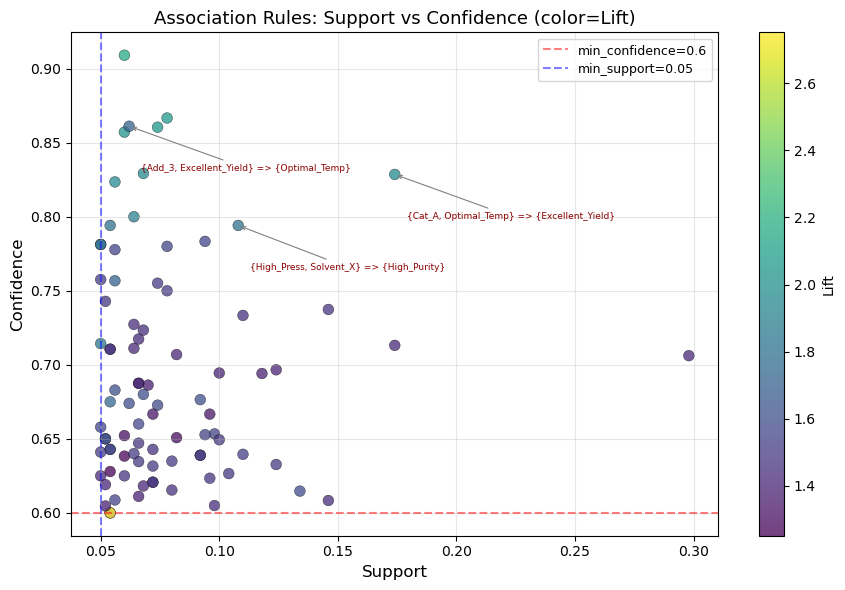

✓ 圖檔已儲存：d:\MyGit\ChemE-3590\Part_2\Unit08\outputs\P2_Unit08_Association_Rule_Learning_Overview\figs\support_confidence_scatter.png


In [10]:
# ====================================================
# 7.1 Support-Confidence 散佈圖
# ====================================================
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    rules_eval['support'],
    rules_eval['confidence'],
    c=rules_eval['lift'],
    s=60,
    cmap='viridis',
    alpha=0.75,
    edgecolors='k',
    linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='Lift')

# 標記閾值線
ax.axhline(y=0.6, color='red', linestyle='--', alpha=0.5, label='min_confidence=0.6')
ax.axvline(x=0.05, color='blue', linestyle='--', alpha=0.5, label='min_support=0.05')

# 標注 Top-3 高分規則
for i, (_, row) in enumerate(rules_filter.head(3).iterrows()):
    ants = ', '.join(sorted(list(row['antecedents'])))
    cons = ', '.join(sorted(list(row['consequents'])))
    label = f"{{{ants}}} => {{{cons}}}"
    ax.annotate(
        label,
        xy=(row['support'], row['confidence']),
        xytext=(row['support'] + 0.005, row['confidence'] - 0.03),
        fontsize=6.5,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
        color='darkred'
    )

ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Association Rules: Support vs Confidence (color=Lift)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'support_confidence_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'support_confidence_scatter.png'}")

### 7.2 規則網絡圖（前項 → 後項，邊粗細表示 Confidence）

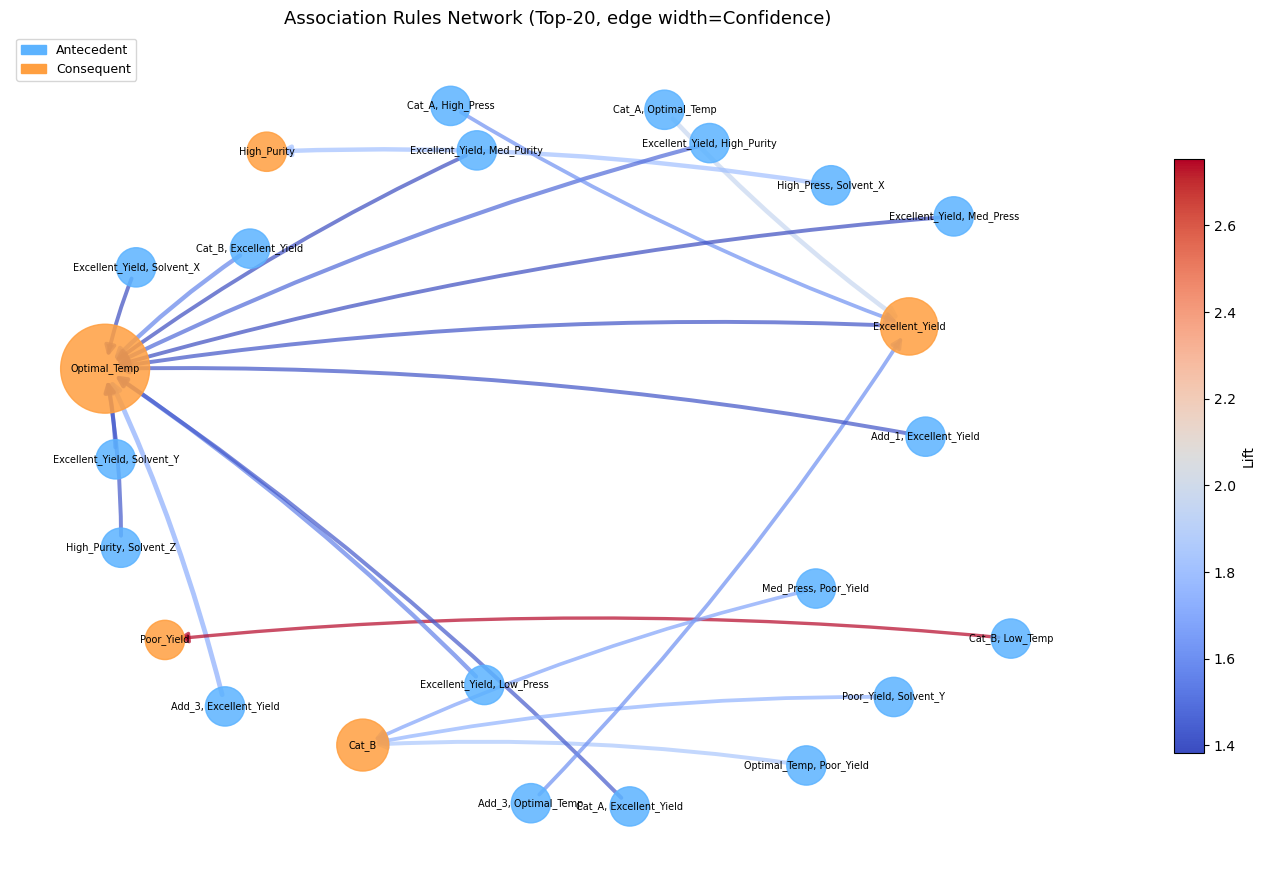

✓ 圖檔已儲存：d:\MyGit\ChemE-3590\Part_2\Unit08\outputs\P2_Unit08_Association_Rule_Learning_Overview\figs\rules_network.png


In [11]:
# ====================================================
# 7.2 規則網絡圖
# ====================================================

# 取 Top-20 規則建圖，避免過於複雜
top20 = rules_filter.head(20)

G = nx.DiGraph()
for _, row in top20.iterrows():
    ant_label = ', '.join(sorted(list(row['antecedents'])))
    con_label = ', '.join(sorted(list(row['consequents'])))
    G.add_edge(ant_label, con_label,
               weight=row['confidence'],
               lift=row['lift'])

fig, ax = plt.subplots(figsize=(14, 9))
pos = nx.spring_layout(G, k=1.5, seed=SEED)

# 節點大小依出度 (out-degree)
node_sizes = [500 + 300 * G.degree(n) for n in G.nodes()]

# 節點顏色：後項節點（yield/purity）標為橙色，前項標為水藍色
consequent_nodes = set(', '.join(sorted(list(r['consequents']))) for _, r in top20.iterrows())
node_colors = ['#FF9F40' if n in consequent_nodes else '#5CB3FF' for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=node_colors, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)

edge_widths = [G[u][v]['weight'] * 4 for u, v in G.edges()]
edge_colors = [G[u][v]['lift'] for u, v in G.edges()]
edges_drawn = nx.draw_networkx_edges(
    G, pos, width=edge_widths, edge_color=edge_colors,
    edge_cmap=plt.cm.coolwarm, arrows=True,
    arrowsize=15, alpha=0.7, ax=ax,
    connectionstyle='arc3,rad=0.05'
)

# 色條
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm,
                            norm=plt.Normalize(vmin=min(edge_colors), vmax=max(edge_colors)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Lift', shrink=0.7)

# 圖例
blue_patch  = mpatches.Patch(color='#5CB3FF', label='Antecedent')
orange_patch = mpatches.Patch(color='#FF9F40', label='Consequent')
ax.legend(handles=[blue_patch, orange_patch], loc='upper left', fontsize=9)

ax.set_title('Association Rules Network (Top-20, edge width=Confidence)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'rules_network.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'rules_network.png'}")

### 7.3 矩陣熱力圖（單一前項 × 後項的 Lift 矩陣）

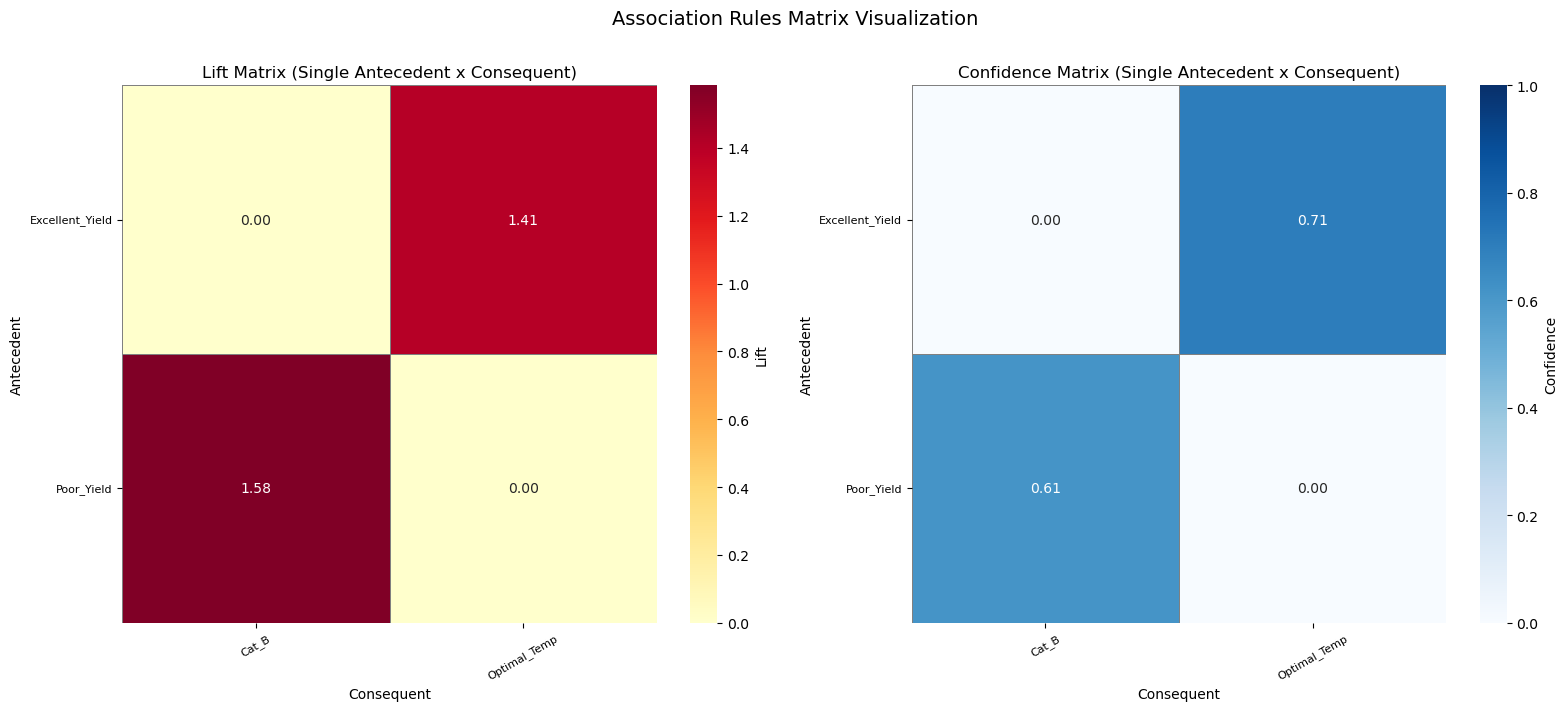

✓ 圖檔已儲存：d:\MyGit\ChemE-3590\Part_2\Unit08\outputs\P2_Unit08_Association_Rule_Learning_Overview\figs\rules_matrix_heatmap.png


In [12]:
# ====================================================
# 7.3 矩陣熱力圖（1-前項 × 1-後項）
# ====================================================

# 篩選單一前項、單一後項的規則
simple_rules = rules_eval[
    (rules_eval['antecedents'].apply(len) == 1) &
    (rules_eval['consequents'].apply(len) == 1)
].copy()

# 建立 Lift 矩陣
ants_list = sorted(set(list(r)[0] for r in simple_rules['antecedents']))
cons_list = sorted(set(list(r)[0] for r in simple_rules['consequents']))

lift_matrix = pd.DataFrame(np.nan, index=ants_list, columns=cons_list)
conf_matrix = pd.DataFrame(np.nan, index=ants_list, columns=cons_list)

for _, row in simple_rules.iterrows():
    a = list(row['antecedents'])[0]
    c = list(row['consequents'])[0]
    lift_matrix.loc[a, c] = row['lift']
    conf_matrix.loc[a, c] = row['confidence']

# 填補 NaN 為 0（表示無規則）
lift_matrix_filled = lift_matrix.fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左圖：Lift 熱力圖
sns.heatmap(
    lift_matrix_filled,
    ax=axes[0],
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='gray',
    cbar_kws={'label': 'Lift'},
    vmin=0, vmax=lift_matrix_filled.max().max()
)
axes[0].set_title('Lift Matrix (Single Antecedent x Consequent)', fontsize=12)
axes[0].set_xlabel('Consequent', fontsize=10)
axes[0].set_ylabel('Antecedent', fontsize=10)
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# 右圖：Confidence 熱力圖
conf_matrix_filled = conf_matrix.fillna(0)
sns.heatmap(
    conf_matrix_filled,
    ax=axes[1],
    annot=True, fmt='.2f',
    cmap='Blues',
    linewidths=0.4,
    linecolor='gray',
    cbar_kws={'label': 'Confidence'},
    vmin=0, vmax=1
)
axes[1].set_title('Confidence Matrix (Single Antecedent x Consequent)', fontsize=12)
axes[1].set_xlabel('Consequent', fontsize=10)
axes[1].set_ylabel('Antecedent', fontsize=10)
axes[1].tick_params(axis='x', rotation=30, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Association Rules Matrix Visualization', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rules_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'rules_matrix_heatmap.png'}")

### 7.4 氣泡圖（Support × Confidence，氣泡大小 = Support × Confidence）

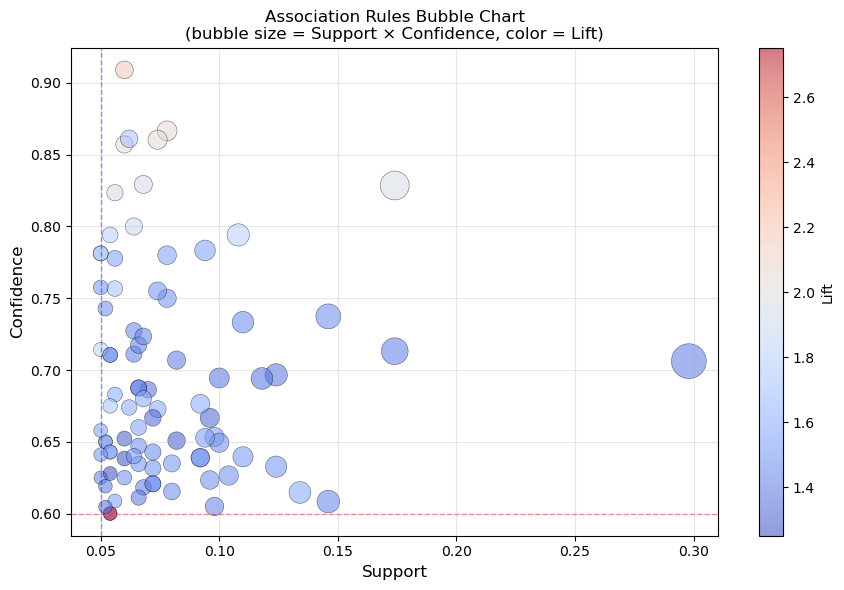

✓ 圖檔已儲存：d:\MyGit\ChemE-3590\Part_2\Unit08\outputs\P2_Unit08_Association_Rule_Learning_Overview\figs\rules_bubble_chart.png


In [13]:
# ====================================================
# 7.4 氣泡圖
# ====================================================
fig, ax = plt.subplots(figsize=(9, 6))

bubble_size = rules_eval['support'] * rules_eval['confidence'] * 3000

sc = ax.scatter(
    rules_eval['support'],
    rules_eval['confidence'],
    s=bubble_size,
    c=rules_eval['lift'],
    cmap='coolwarm',
    alpha=0.55,
    edgecolors='k',
    linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Lift')

ax.axhline(y=0.6, color='red', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(x=0.05, color='blue', linestyle='--', alpha=0.4, linewidth=1)

ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Association Rules Bubble Chart\n(bubble size = Support × Confidence, color = Lift)',
             fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rules_bubble_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'rules_bubble_chart.png'}")

---
## 8. 化工應用整合：從規則到配方建議

本節展示如何根據挖掘到的規則，**轉化為具體的操作建議**，並驗證嵌入數據中的三條設計規則是否被成功發現。

In [14]:
# ====================================================
# 8.1 驗證設計規則是否被成功發現
# ====================================================

# 設計的三條目標規則
target_rules = [
    ({'Cat_A', 'Optimal_Temp'}, {'Excellent_Yield'},  "Rule 1: Cat_A + Optimal_Temp => Excellent_Yield"),
    ({'Solvent_X', 'High_Press'}, {'High_Purity'},    "Rule 2: Solvent_X + High_Press => High_Purity"),
    ({'Cat_B', 'Low_Temp'},       {'Poor_Yield'},      "Rule 3: Cat_B + Low_Temp => Poor_Yield"),
]

all_rules_found = rules_eval.copy()

print("=== 設計規則驗證 ===\n")
for ant_set, con_set, desc in target_rules:
    # 搜尋匹配的規則
    matches = all_rules_found[
        (all_rules_found['antecedents'].apply(lambda x: ant_set.issubset(x))) &
        (all_rules_found['consequents'].apply(lambda x: con_set.issubset(x)))
    ]
    if not matches.empty:
        best = matches.sort_values('lift', ascending=False).iloc[0]
        print(f"  ✓ 找到：{desc}")
        print(f"    Support={best['support']:.3f}, Confidence={best['confidence']:.3f}, Lift={best['lift']:.2f}")
    else:
        # 嘗試更寬鬆匹配（任一前項包含）
        loose_matches = all_rules_found[
            all_rules_found['antecedents'].apply(lambda x: bool(ant_set & x)) &
            all_rules_found['consequents'].apply(lambda x: bool(con_set & x))
        ]
        if not loose_matches.empty:
            best = loose_matches.sort_values('lift', ascending=False).iloc[0]
            print(f"  ~ 部分找到：{desc}")
            print(f"    {set(best['antecedents'])} => {set(best['consequents'])}")
            print(f"    Support={best['support']:.3f}, Confidence={best['confidence']:.3f}, Lift={best['lift']:.2f}")
        else:
            print(f"  ✗ 未找到：{desc}（可能需降低 min_support）")

=== 設計規則驗證 ===

  ✓ 找到：Rule 1: Cat_A + Optimal_Temp => Excellent_Yield
    Support=0.060, Confidence=0.909, Lift=2.15
  ✓ 找到：Rule 2: Solvent_X + High_Press => High_Purity
    Support=0.108, Confidence=0.794, Lift=1.80
  ✓ 找到：Rule 3: Cat_B + Low_Temp => Poor_Yield
    Support=0.054, Confidence=0.600, Lift=2.75


In [15]:
# ====================================================
# 8.2 規則轉化為配方建議
# ====================================================

print("=" * 60)
print("化工配方建議報告")
print("=" * 60)

# 依據 score 排序，取前 5 條可操作規則
top5_rules = rules_filter[
    rules_filter['consequents'].apply(
        lambda x: bool({'Excellent_Yield', 'High_Purity'} & x)
    )
].head(5)

recommendations = []
for i, (_, row) in enumerate(top5_rules.iterrows(), 1):
    ants = sorted(list(row['antecedents']))
    cons = sorted(list(row['consequents']))
    rec = {
        'rank': i,
        'conditions': ants,
        'expected_outcome': cons,
        'confidence': row['confidence'],
        'lift': row['lift'],
        'support': row['support'],
    }
    recommendations.append(rec)

for rec in recommendations:
    print(f"\n  建議 {rec['rank']}：")
    print(f"    操作條件: {rec['conditions']}")
    print(f"    預期結果: {rec['expected_outcome']}")
    print(f"    置信度: {rec['confidence']:.1%}  (每 100 次中預期 {rec['confidence']*100:.0f} 次達標)")
    print(f"    提升度: {rec['lift']:.2f}  (較隨機條件提升 {(rec['lift']-1)*100:.0f}%)")
    print(f"    普遍性: {rec['support']:.1%}  (佔全部配方的 {rec['support']*100:.0f}%)")

print("\n" + "=" * 60)
print("注意：關聯規則只揭示相關性，因果關係需透過實驗驗證。")
print("=" * 60)

化工配方建議報告

  建議 1：
    操作條件: ['Cat_A', 'Optimal_Temp']
    預期結果: ['Excellent_Yield']
    置信度: 82.9%  (每 100 次中預期 83 次達標)
    提升度: 1.96  (較隨機條件提升 96%)
    普遍性: 17.4%  (佔全部配方的 17%)

  建議 2：
    操作條件: ['High_Press', 'Solvent_X']
    預期結果: ['High_Purity']
    置信度: 79.4%  (每 100 次中預期 79 次達標)
    提升度: 1.80  (較隨機條件提升 80%)
    普遍性: 10.8%  (佔全部配方的 11%)

  建議 3：
    操作條件: ['Cat_A', 'High_Press']
    預期結果: ['Excellent_Yield']
    置信度: 67.6%  (每 100 次中預期 68 次達標)
    提升度: 1.60  (較隨機條件提升 60%)
    普遍性: 9.2%  (佔全部配方的 9%)

  建議 4：
    操作條件: ['Add_3', 'Optimal_Temp']
    預期結果: ['Excellent_Yield']
    置信度: 67.4%  (每 100 次中預期 67 次達標)
    提升度: 1.60  (較隨機條件提升 60%)
    普遍性: 6.2%  (佔全部配方的 6%)

  建議 5：
    操作條件: ['Optimal_Temp', 'Solvent_Y']
    預期結果: ['Excellent_Yield']
    置信度: 64.0%  (每 100 次中預期 64 次達標)
    提升度: 1.52  (較隨機條件提升 52%)
    普遍性: 11.0%  (佔全部配方的 11%)

注意：關聯規則只揭示相關性，因果關係需透過實驗驗證。


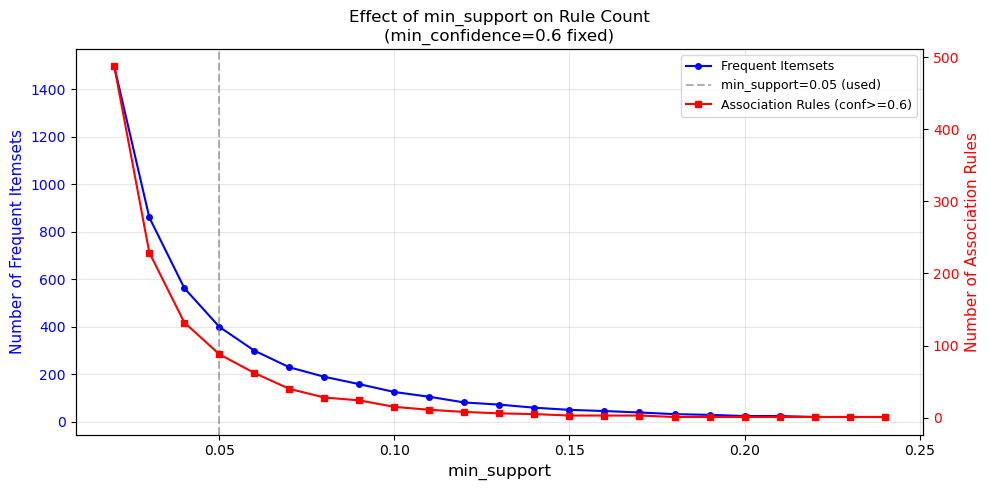

✓ 圖檔已儲存：d:\MyGit\ChemE-3590\Part_2\Unit08\outputs\P2_Unit08_Association_Rule_Learning_Overview\figs\threshold_effect.png

  當 min_support=0.05 時：400 個頻繁項目集，88 條規則


In [16]:
# ====================================================
# 8.3 min_support 對規則數量的影響（閾值選擇曲線）
# ====================================================
sup_range = np.arange(0.02, 0.25, 0.01)
n_itemsets_list = []
n_rules_list = []

for s in sup_range:
    fi = fpgrowth(df_chem, min_support=s, use_colnames=True)
    n_itemsets_list.append(len(fi))
    if len(fi) > 0:
        r = association_rules(fi, metric="confidence", min_threshold=0.6,
                              num_itemsets=len(fi))
        n_rules_list.append(len(r))
    else:
        n_rules_list.append(0)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(sup_range, n_itemsets_list, 'b-o', markersize=4, label='Frequent Itemsets')
ax2.plot(sup_range, n_rules_list, 'r-s', markersize=4, label='Association Rules (conf>=0.6)')

ax1.set_xlabel('min_support', fontsize=12)
ax1.set_ylabel('Number of Frequent Itemsets', color='blue', fontsize=11)
ax2.set_ylabel('Number of Association Rules', color='red', fontsize=11)
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')

# 標記建議閾值
ax1.axvline(x=0.05, color='gray', linestyle='--', alpha=0.6, label='min_support=0.05 (used)')
ax1.set_title('Effect of min_support on Rule Count\n(min_confidence=0.6 fixed)', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'threshold_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'threshold_effect.png'}")
print(f"\n  當 min_support=0.05 時：{n_itemsets_list[3]} 個頻繁項目集，{n_rules_list[3]} 條規則")

---
## 9. 總結

### 本 Notebook 演練內容回顧

| 章節 | 主題 | 核心技巧 |
|------|------|---------|
| 2 | 基本概念 | 手動計算 Support / Confidence / Lift，用 mlxtend 驗證 |
| 3 | Apriori 逐步追蹤 | 逐輪掃描 L1→L2→L3，觀察 Apriori 剪枝原理 |
| 4 | 演算法比較 | Apriori vs FP-Growth 速度與結果一致性驗證 |
| 5 | 進階指標 | Conviction、Leverage、Zhang's Metric、Kulczynski |
| 6 | 規則過濾 | Lift 閾值、卡方顯著性、長度限制、綜合評分排序 |
| 7 | 視覺化 | 散佈圖、網絡圖、矩陣熱力圖、氣泡圖 |
| 8 | 化工應用 | 設計規則驗證、配方建議報告、閾值選擇曲線 |

### 關鍵結論
1. **三大指標**：Support 衡量普遍性，Confidence 衡量可靠性，Lift 衡量關聯強度
2. **演算法選擇**：兩者結果相同，FP-Growth 在大數據集上效率更高
3. **規則品質**：單靠 Confidence 不夠，Lift > 1.2 且統計顯著才有意義
4. **閾值調整**：從保守閾值開始，依「拐點」選擇 min_support
5. **因果性**：關聯規則只揭示**相關性**，因果關係必須透過實驗設計（DOE）驗證

### 下一步
- **Unit08_Apriori_Algorithm**：Apriori 演算法深入實作
- **Unit08_FP_Growth_Algorithm**：FP-Growth 演算法深入實作
- **Unit08_Association_Rule_Learning_Homework**：綜合化工案例練習